# 2. Análisis Exploratorio de Datos (EDA)

El análisis exploratorio de datos (EDA por sus siglas en inglés) es el proceso de examinar y visualizar datos para resumir sus principales características, frecuentemente utilizando técnicas estadísticas y gráficas, con el objetivo de comprender mejor las distribuciones, relaciones y posibles anomalías antes de aplicar modelos predictivos. Este paso es crucial para identificar patrones, detectar errores y sugerir hipótesis para el análisis posterior.

Exploraremos los datos limpios para comprender las relaciones entre las variables de supervivenia.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('data/titanic_clean.csv')
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


## Supervivencia por Género

In [3]:
df['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

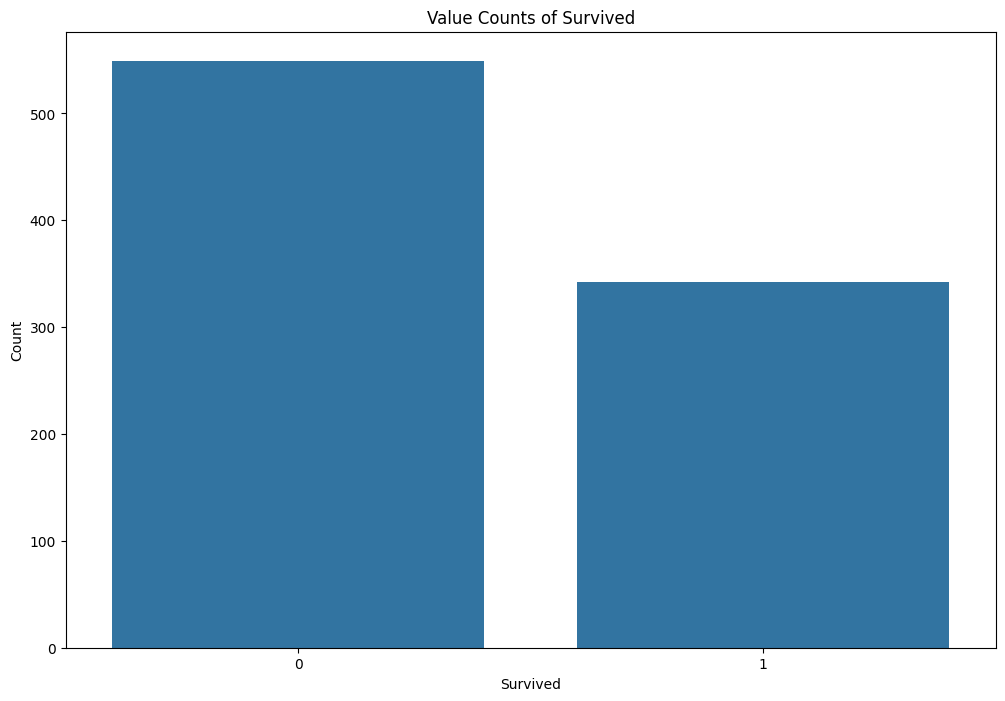

In [4]:
plt.figure(figsize=(12, 8))

sns.barplot(x = df['Survived'].value_counts().index, y = df['Survived'].value_counts())
plt.title('Value Counts of Survived')
plt.xlabel('Survived')
plt.ylabel('Count')
plt.show()

C:\Users\rope4001\AppData\Local\Temp\1\ipykernel_15936\1505180528.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Sex', y='Survived', data=df, palette='viridis')


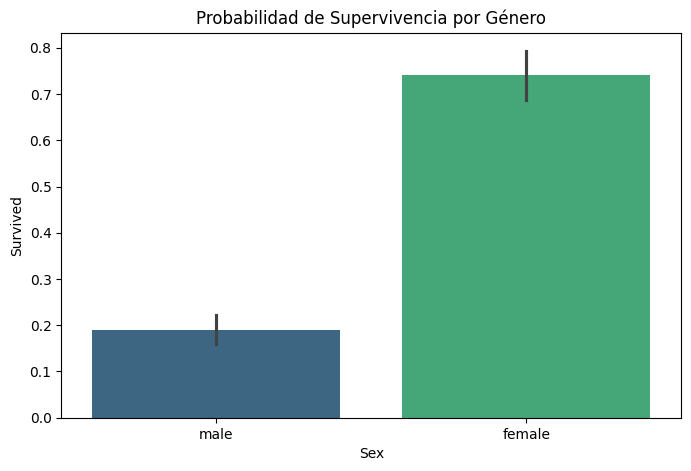

In [2]:
plt.figure(figsize=(8,5))
sns.barplot(x='Sex', y='Survived', data=df, palette='viridis')
plt.title('Probabilidad de Supervivencia por Género')
plt.show()

## Supervivencia por Clase

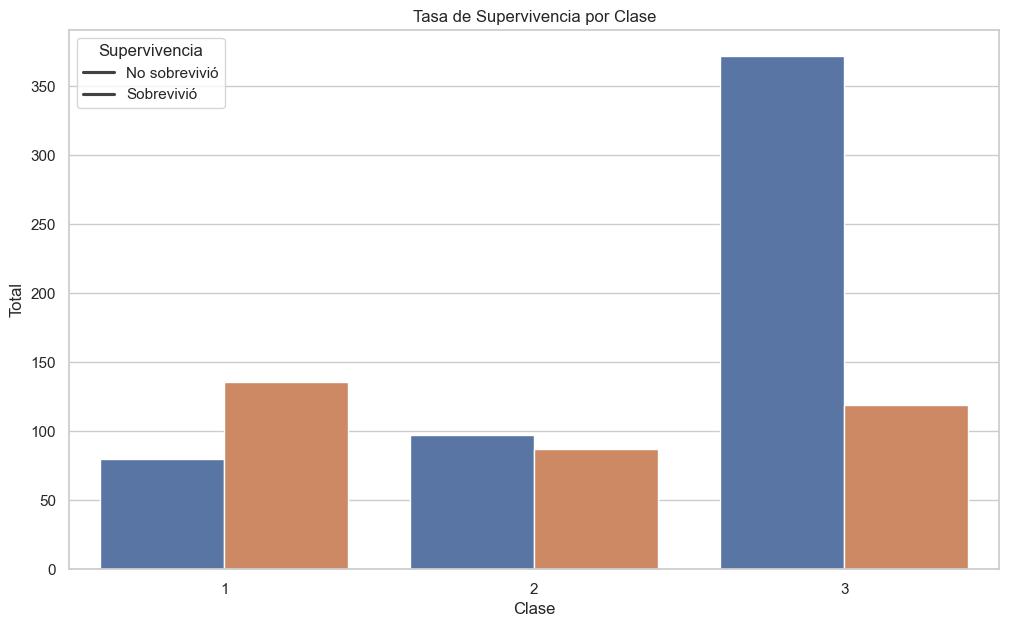

In [12]:
# Agrupar por clase y supervivencia
survival_by_class = df.groupby(['Pclass', 'Survived']).size().reset_index(name='Total')

# Configurar estilo
sns.set(style="whitegrid")

# Crear gráfico de barras agrupadas
plt.figure(figsize=(12,7))
sns.barplot(data=survival_by_class, x='Pclass', y='Total', hue='Survived')

# Personalizar etiquetas y título
plt.title('Tasa de Supervivencia por Clase')
plt.xlabel('Clase')
plt.ylabel('Total')
plt.legend(title='Supervivencia', labels=['No sobrevivió', 'Sobrevivió'])

plt.show()


C:\Users\rope4001\AppData\Local\Temp\1\ipykernel_15936\3078854192.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Pclass', y= 'Survived', data=df, palette='magma')


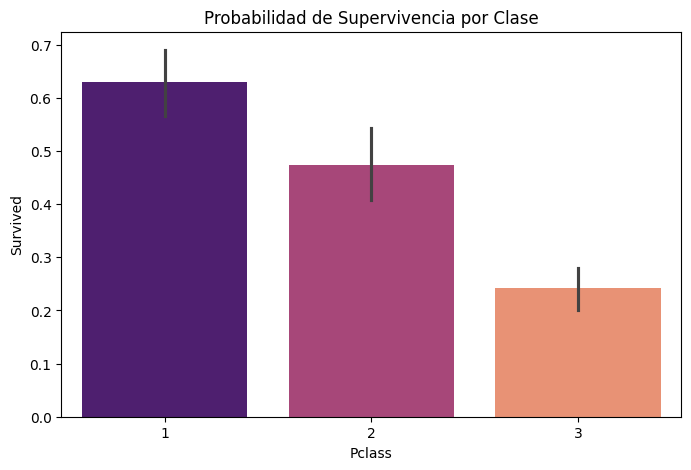

In [3]:
plt.figure(figsize=(8,5))
sns.barplot(x='Pclass', y= 'Survived', data=df, palette='magma')
plt.title('Probabilidad de Supervivencia por Clase')
plt.show()

## Supervivencia por Sexo

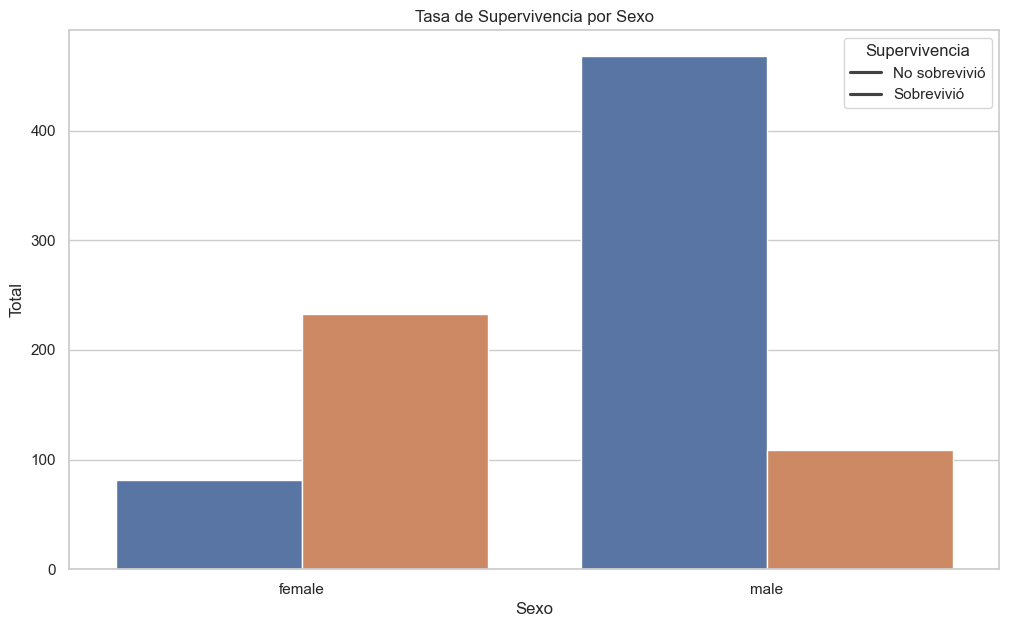

In [11]:
# Agrupar por clase y supervivencia
survival_by_class = df.groupby(['Sex', 'Survived']).size().reset_index(name='Total')

# Configurar estilo
sns.set(style="whitegrid")

# Crear gráfico de barras agrupadas
plt.figure(figsize=(12,7))
sns.barplot(data=survival_by_class, x='Sex', y='Total', hue='Survived')

# Personalizar etiquetas y título
plt.title('Tasa de Supervivencia por Sexo')
plt.xlabel('Sexo')
plt.ylabel('Total')
plt.legend(title='Supervivencia', labels=['No sobrevivió', 'Sobrevivió'])

plt.show()

## Distribución de Edades

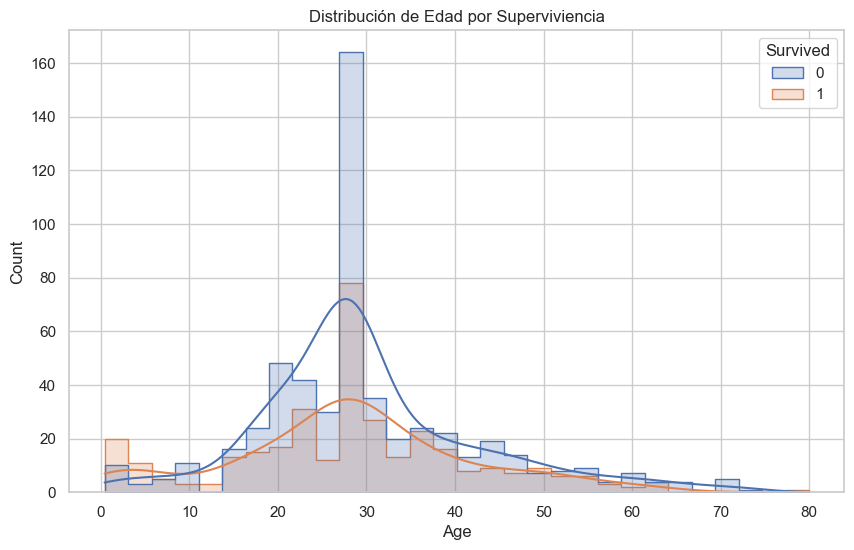

In [14]:
plt.figure(figsize=(10,6))
sns.histplot(data=df, x='Age', hue= 'Survived', kde=True, element='step')
plt.title('Distribución de Edad por Superviviencia')
plt.show()

Esta gráfica muestra cómo la edad influía en la probabilidad de sobrevivir en el Titanic.

**Observaciones:**  

- El pico principal alrededor de los 30 años indica una alta concentración de adultos jóvenes.
- La curva azul (0 = no sobrevivió) es más pronunciada en edades medias, lo que sugiere que los adultos fueron los más afectados.
- La curva naranja (1 = sobrevivió) es más dispersa, con presencia en niños y jóvenes adultos, reflejando mayor prioridad en el rescate.
- En los extremos (mayores de 60 años) hay poca presencia en ambos grupos, indicando menor cantidad de pasajeros mayores.

La supervivencia fue más común entre edades menores y jóvenes adultos, mientras que los adultos de 25–40 años concentraron la mayor cantidad de víctimas.

## Correlación entre variables numéricas

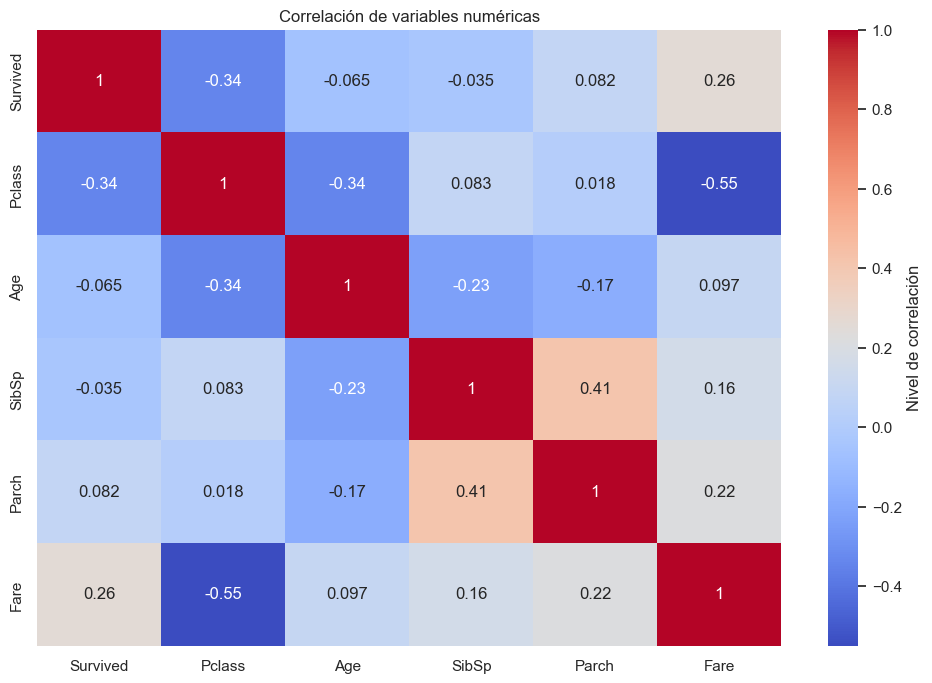

In [15]:
plt.figure(figsize = (12, 8))
sns.heatmap(df[['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']].corr(), 
            annot=True, 
            cbar=True,  # Activar la barra de colores
            cmap='coolwarm',  # Cambiar la paleta de colores
            cbar_kws={'label': 'Nivel de correlación'})  # Etiqueta para la barra de colores
plt.title('Correlación de variables numéricas')
plt.show()